# Question 1

In [17]:
# imports
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from jedi.debug import print_to_stdout

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

#datasets
transform = transforms.ToTensor()

train_data = datasets.SVHN(
    root='./Datasets', split='train', download=True, transform=transform
)

test_data = datasets.SVHN(
    root='./Datasets', split='test', download=True, transform=transform
)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_data = DataLoader(test_data, batch_size=64, shuffle=False)

In [2]:
images,labels = next(iter(train_loader))
print(f"Images shape: {images.shape}")
print(f"Label shape: {labels.shape}")

Images shape: torch.Size([64, 3, 32, 32])
Label shape: torch.Size([64])


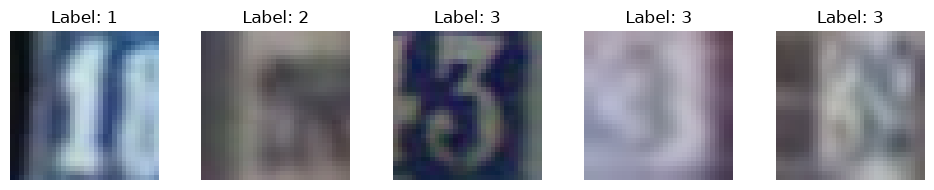

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    img = images[i].permute(1, 2, 0)
    axes[i].imshow(img)
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis("off")
    plt.tight_layout()
plt.show()

In [4]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=16,
            padding=1,
            kernel_size=3,
        )
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )
        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        )
        # Fully connected layer
        self.fc = nn.Linear(
            #2048 input size & 10 output size
            32*8*8,10
        )

    def forward(self,x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = torch.relu(x)
        x = self.pool(x)
        x = torch.flatten(x,1)
        x = self.fc(x)
        return x
model = CNN()

In [5]:
x = model.conv1(images)
print(f"Before Conv shape: {images.shape}")
print(f"Output layer1 shape: {x.shape}")
# print(f"before relu \n{x[0][0]}\n")
x = torch.relu(x)
# print(f"after relu \n{x[0][0]}\n")

print(f"After ReLU shape: {x.shape}")
x = model.pool(x)
print(f"After Pool shape: {x.shape}")

print("Input to Conv2 :", x.shape)

x = model.conv2(x)
print("output of Conv2 :", x.shape)

x = torch.relu(x)
print("ReLU:", x.shape)

x = model.pool(x)
print("POOL2 :", x.shape)


x = torch.flatten(x,1)
print(f"after flatten : {x.shape}")
ypred = model.fc(x)
print(f"after predict: {ypred.shape}")

Before Conv shape: torch.Size([64, 3, 32, 32])
Output layer1 shape: torch.Size([64, 16, 32, 32])
After ReLU shape: torch.Size([64, 16, 32, 32])
After Pool shape: torch.Size([64, 16, 16, 16])
Input to Conv2 : torch.Size([64, 16, 16, 16])
output of Conv2 : torch.Size([64, 32, 16, 16])
ReLU: torch.Size([64, 32, 16, 16])
POOL2 : torch.Size([64, 32, 8, 8])
after flatten : torch.Size([64, 2048])
after predict: torch.Size([64, 10])


# Forward

In [6]:
conv_a = nn.Conv2d(3, 16, 3, padding=1, stride=1)
conv_b = nn.Conv2d(3, 16, 3, padding=0, stride=1)
conv_c = nn.Conv2d(3, 16, 3, padding=1, stride=2)
print("A:", conv_a(images).shape)
print("B:", conv_b(images).shape)
print("C:", conv_c(images).shape)

A: torch.Size([64, 16, 32, 32])
B: torch.Size([64, 16, 30, 30])
C: torch.Size([64, 16, 16, 16])


# Training model 

In [10]:
critreion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01

)
scheduler = torch.optim.lr_scheduler.StepLR(
optimizer,
step_size=2, # Every 5 epochs
gamma=0.5 # Multiply learning rate by 0.5
)
weights_before = model.conv1.weight.detach().clone()

weights_before.shape

torch.Size([16, 3, 3, 3])

In [11]:
epochs = 10
torch.random.manual_seed(0)
epoch_loss_history = []
for epoch in range(epochs):
    running_loss = 0.0
    model.train()
    for images,labels in train_loader:
        #forward
        logits = model(images)

        loss = critreion(logits,labels)
        optimizer.zero_grad()
        #back propagation
        loss.backward()
        #update parameters
        optimizer.step()

        running_loss += loss.item()
    scheduler.step()
    epoch_loss = running_loss / len(train_loader)
    epoch_loss_history.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{epochs}]  Loss: {epoch_loss:.4f}")


Epoch [1/10]  Loss: 0.5788
Epoch [2/10]  Loss: 0.5475
Epoch [3/10]  Loss: 0.4373
Epoch [4/10]  Loss: 0.4175
Epoch [5/10]  Loss: 0.3608
Epoch [6/10]  Loss: 0.3485
Epoch [7/10]  Loss: 0.3138
Epoch [8/10]  Loss: 0.3089
Epoch [9/10]  Loss: 0.2894
Epoch [10/10]  Loss: 0.2854


In [16]:
weights_after = model.conv1.weight.data.clone()
changed = not torch.allclose(weights_before, weights_after, atol=1e-6)
print(f"Weights changed: {changed}")

Weights changed: True


# Final validation

In [27]:
test_images, test_labels = next(iter(test_data))
print(f"Images shape: {test_images.shape}")
model.eval()
with torch.no_grad():
    logits = model(test_images)
    predictions = logits.argmax(dim=1)
    print("True labels :", test_labels[:10])
    print("Predictions :", predictions[:10])
correct= sum(test_labels == predictions)
accuracy  = correct/ len(test_labels)
print(accuracy)

Images shape: torch.Size([64, 3, 32, 32])
True labels : tensor([5, 2, 1, 0, 6, 1, 9, 1, 1, 8])
Predictions : tensor([5, 2, 1, 0, 6, 1, 9, 1, 1, 8])
tensor(0.8438)


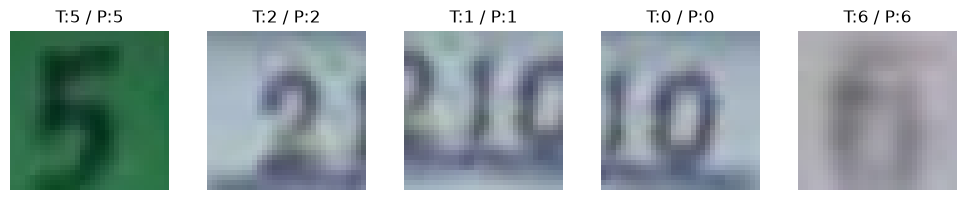

In [25]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    img = test_images[i].permute(1, 2, 0)
    axes[i].imshow(img)
    axes[i].set_title(
    f"T:{test_labels[i].item()} / P:{predictions[i].item()}"
    )
    axes[i].axis("off")
plt.tight_layout()
plt.show()

torch.Size([1, 16, 32, 32])


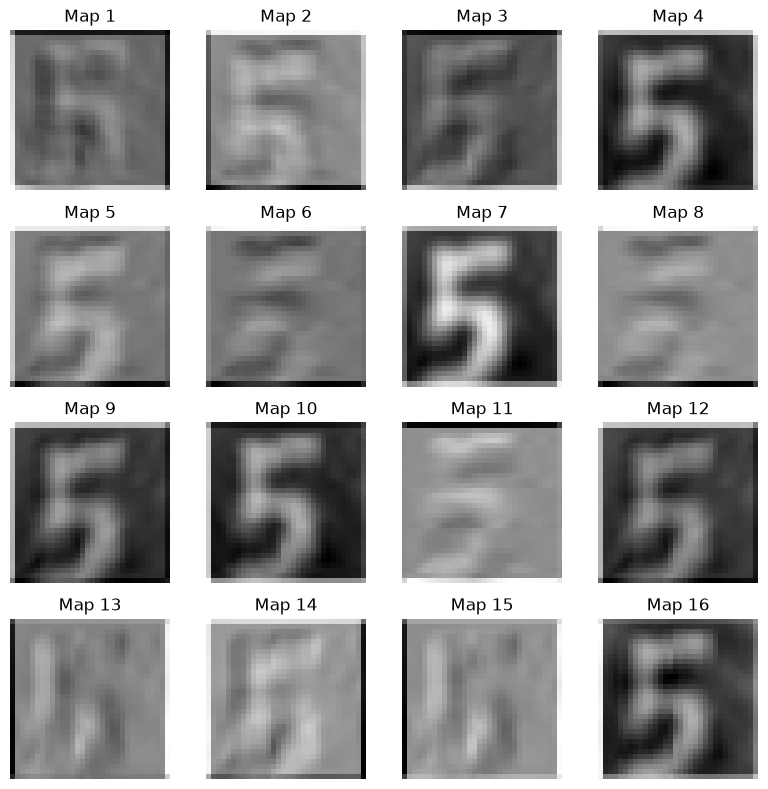

In [34]:
image = test_images[0].unsqueeze(0)
with torch.no_grad():
    feature_maps = model.conv1(image)
    print(feature_maps.shape)


fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(
    feature_maps[0, i].cpu(),
    cmap="gray"
    )
    ax.set_title(f"Map {i+1}")
    ax.axis("off")
plt.tight_layout()
plt.show()